In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [38]:
customer_master = pd.read_excel("Customer_Master_Data.xlsx")
customer_transactions = pd.read_csv('Customer_Transactions.csv')

In [39]:
print("=== Customer Master Data ===")
print(f"Shape: {customer_master.shape}")
print("\nFirst 5 rows:")
print(customer_master.head())

=== Customer Master Data ===
Shape: (1000, 9)

First 5 rows:
  CustomerID            Name                    Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava          pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli        mkalita@sarin.com  Female   48  Kolkata   
2  CUST10002      Kiara Behl     apteanay@hotmail.com    Male   75  Kolkata   
3  CUST10003  Vaibhav Sankar  bseshadri@choudhry.info    Male   62     Pune   
4  CUST10004    Shray D’Alia   bdhillon@toor-mall.com    Male   55    Delhi   

  MaritalStatus  NumChildren   JoinDate  
0      Divorced            0 2021-02-22  
1       Married            0 2023-12-06  
2       Widowed            2 2023-08-23  
3      Divorced            2 2022-11-17  
4      Divorced            0 2022-12-04  


In [40]:
print("\n=== Customer Transactions Data ===")
print(f"Shape: {customer_transactions.shape}")
print("\nFirst 5 rows:")
print(customer_transactions.head())



=== Customer Transactions Data ===
Shape: (23050, 3)

First 5 rows:
  CustomerID TransactionDate  TransactionAmount
0  CUST10771         7/31/23            2383.07
1  CUST10100         3/10/24             497.54
2  CUST10031         2/17/25             536.78
3  CUST10987         7/17/23             314.89
4  CUST10831        12/15/24            2543.19


In [41]:
print("\n=== Customer Master Data Info ===")
customer_master.info()



=== Customer Master Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB


In [47]:
print("\n=== Transactions Data Info ===")
customer_transactions.info()


=== Transactions Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   TransactionDate    23050 non-null  datetime64[ns]
 2   TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 540.4+ KB


In [48]:
customer_master['JoinDate'] = pd.to_datetime(customer_master['JoinDate'])
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

In [49]:
print("=== Missing Values in Master Data ===")
print(customer_master.isnull().sum())

=== Missing Values in Master Data ===
CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64


In [50]:
print("\n=== Missing Values in Transactions ===")
print(customer_transactions.isnull().sum())



=== Missing Values in Transactions ===
CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


In [51]:
duplicate_customers = customer_master['CustomerID'].duplicated().sum()
print(f"\nDuplicate CustomerIDs in master data: {duplicate_customers}")



Duplicate CustomerIDs in master data: 0


In [52]:
missing_customers = customer_transactions['CustomerID'].isin(customer_master['CustomerID']).sum()
print(f"Valid CustomerIDs in transactions: {missing_customers}/{len(customer_transactions)}")


Valid CustomerIDs in transactions: 23050/23050


In [53]:
customer_master['Gender'] = customer_master['Gender'].fillna('Not Disclosed')
customer_master['MaritalStatus'] = customer_master['MaritalStatus'].fillna('Not Disclosed')
print("\nData cleaning completed!")


Data cleaning completed!


In [54]:
print("=== Customer Demographics Summary ===")
print(f"Age range: {customer_master['Age'].min()} - {customer_master['Age'].max()} years")
print(f"Cities distribution:")
print(customer_master['City'].value_counts().head(10))


=== Customer Demographics Summary ===
Age range: 18 - 75 years
Cities distribution:
City
Lucknow      110
Jaipur       109
Hyderabad    104
Ahmedabad    102
Bangalore    102
Delhi         99
Mumbai        99
Pune          93
Kolkata       91
Chennai       91
Name: count, dtype: int64


In [55]:
print("\n=== Transaction Statistics ===")
print(f"Total transactions: {len(customer_transactions)}")
print(f"Total revenue: ₹{customer_transactions['TransactionAmount'].sum():,.2f}")
print(f"Average transaction value: ₹{customer_transactions['TransactionAmount'].mean():.2f}")



=== Transaction Statistics ===
Total transactions: 23050
Total revenue: ₹23,053,199.66
Average transaction value: ₹1000.14


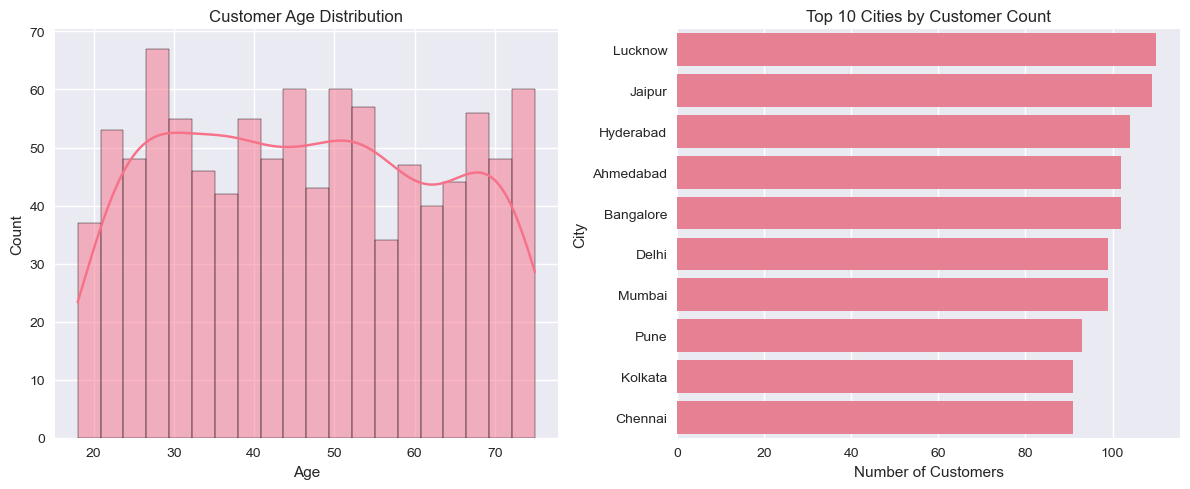

In [82]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(customer_master['Age'], bins=20, kde=True)
plt.title('Customer Age Distribution')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
city_counts = customer_master['City'].value_counts().head(10)
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title('Top 10 Cities by Customer Count')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(customer_transactions['TransactionAmount'], bins=30, kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount (₹)')

plt.subplot(1, 2, 2)
plt.boxplot(customer_transactions['TransactionAmount'])
plt.title('Transaction Amount Boxplot')
plt.ylabel('Amount (₹)')
plt.tight_layout()
plt.show()


In [63]:
latest_date = customer_transactions['TransactionDate'].max()
reference_date = latest_date + pd.Timedelta(days=1)
print(f"Reference Date for RFM Analysis: {reference_date}")


Reference Date for RFM Analysis: 2025-07-30 00:00:00


In [64]:
rfm_data = customer_transactions.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days, 
    'TransactionDate': 'count',
    'TransactionAmount': 'sum'  
}).reset_index()


In [65]:
rfm_data = customer_transactions.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days,
    'TransactionAmount': 'sum'
}).reset_index()
rfm_data.columns = ['CustomerID', 'Recency', 'Monetary']


In [66]:
frequency_data = customer_transactions.groupby('CustomerID').size().reset_index(name='Frequency')
rfm_data = pd.merge(rfm_data, frequency_data, on='CustomerID')
print("\nRFM Data Preview:")
print(rfm_data.head())
print(f"\nRFM Statistics:")
print(rfm_data[['Recency', 'Frequency', 'Monetary']].describe())


RFM Data Preview:
  CustomerID  Recency  Monetary  Frequency
0  CUST10000       13  21265.49         23
1  CUST10001       35  28654.31         30
2  CUST10002       18  23884.03         24
3  CUST10003       81  24206.03         25
4  CUST10004        8  25565.30         19

RFM Statistics:
           Recency    Frequency     Monetary
count  1000.000000  1000.000000   1000.00000
mean     50.794000    23.050000  23053.19966
std      58.124418     4.810472   5622.44101
min       1.000000     6.000000   5052.69000
25%      13.000000    20.000000  18965.46250
50%      32.000000    23.000000  22969.82000
75%      69.000000    26.000000  26827.39250
max     524.000000    38.000000  44784.99000


In [67]:
def score_rfm(df, metric, ascending=False):
    """
    Score RFM metrics on 1-5 scale
    ascending=False means higher values get higher scores (except Recency)
    """
    quartiles = pd.qcut(df[metric], q=5, labels=False, duplicates='drop')
    return quartiles + 1 

In [69]:
rfm_data['R_Score'] = score_rfm(rfm_data, 'Recency', ascending=True) 
rfm_data['F_Score'] = score_rfm(rfm_data, 'Frequency', ascending=False) 
rfm_data['M_Score'] = score_rfm(rfm_data, 'Monetary', ascending=False)  
print("RFM Scores Distribution:")
print(rfm_data[['R_Score', 'F_Score', 'M_Score']].value_counts().head(10))

RFM Scores Distribution:
R_Score  F_Score  M_Score
3        1        1          37
1        5        5          35
5        1        1          34
2        1        1          33
1        1        1          28
4        1        1          26
3        5        5          26
1        4        4          22
2        5        5          22
5        2        2          21
Name: count, dtype: int64


In [70]:
rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)
print("\nCombined RFM Scores:")
print(rfm_data['RFM_Score'].value_counts().head(10))


Combined RFM Scores:
RFM_Score
311    37
155    35
511    34
211    33
111    28
355    26
411    26
144    22
255    22
522    21
Name: count, dtype: int64


In [71]:
def segment_customers(row):
    """Assign segment labels based on RFM scores"""
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 1 and f <= 2:
        return "Lost"
    elif m >= 4 and f >= 2 and r >= 3:
        return "Big Spenders"
    elif r >= 4 and f >= 4 and m <= 2:
        return "New Loyalists"
    elif r <= 2 and f <= 2 and m <= 2:
        return "New Customers"
    else:
        return "Others"

In [72]:
rfm_data['Segment'] = rfm_data.apply(segment_customers, axis=1)
print("Customer Segments Distribution:")
segment_counts = rfm_data['Segment'].value_counts()
print(segment_counts)


Customer Segments Distribution:
Segment
At Risk                228
Others                 219
Loyal Customers        170
Potential Loyalists    110
Champions              101
Lost                    91
New Customers           73
Big Spenders             6
New Loyalists            2
Name: count, dtype: int64


In [73]:
customer_rfm = pd.merge(customer_master, rfm_data, on='CustomerID', how='left')

print("\n=== Segment Analysis by Age Group ===")
customer_rfm['Age_Group'] = pd.cut(customer_rfm['Age'], 
                                  bins=[0, 30, 45, 60, 100], 
                                  labels=['<30', '30-45', '45-60', '60+'])
segment_age = pd.crosstab(customer_rfm['Segment'], customer_rfm['Age_Group'], margins=True)
print(segment_age)


=== Segment Analysis by Age Group ===
Age_Group            <30  30-45  45-60  60+   All
Segment                                          
At Risk               41     65     65   57   228
Big Spenders           1      4      0    1     6
Champions             25     26     28   22   101
Lost                  21     20     23   27    91
Loyal Customers       45     43     43   39   170
New Customers         15     27     13   18    73
New Loyalists          1      1      0    0     2
Others                51     62     57   49   219
Potential Loyalists   23     25     27   35   110
All                  223    273    256  248  1000


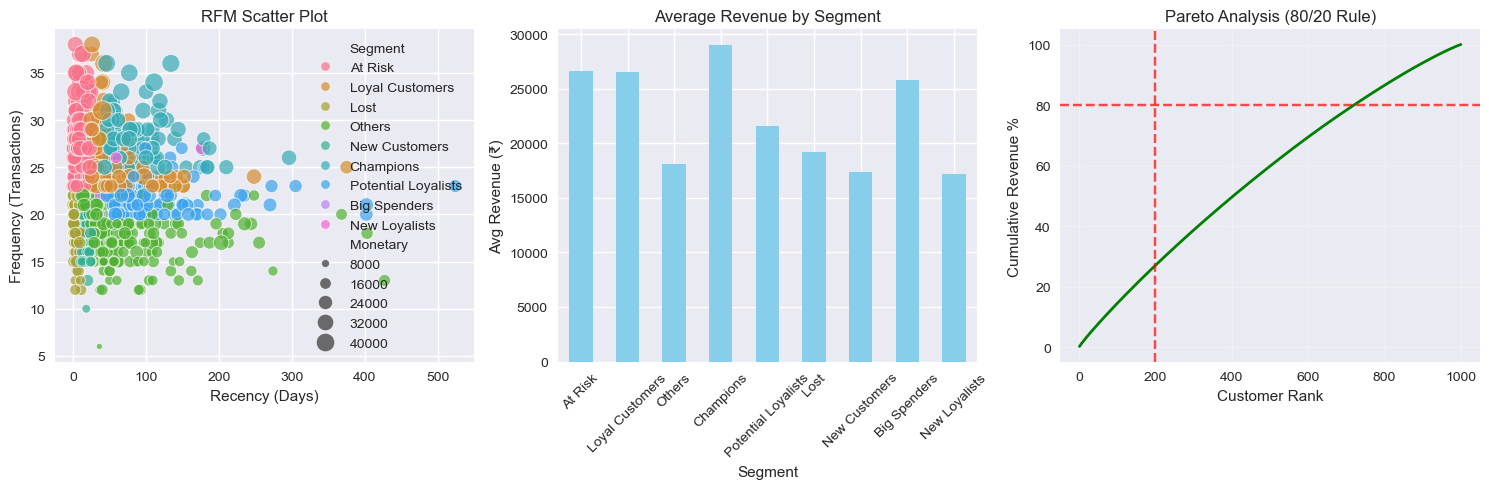

In [78]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(data=rfm_data, x='Recency', y='Frequency', hue='Segment', size='Monetary', 
                sizes=(20, 200), alpha=0.7)
plt.title('RFM Scatter Plot')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency (Transactions)')

plt.subplot(1, 3, 2)
segment_revenue = rfm_data.groupby('Segment')['Monetary'].agg(['sum', 'count']).sort_values('sum', ascending=False)
segment_revenue['avg_revenue'] = segment_revenue['sum'] / segment_revenue['count']
segment_revenue['avg_revenue'].plot(kind='bar', color='skyblue')
plt.title('Average Revenue by Segment')
plt.ylabel('Avg Revenue (₹)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
customer_revenue = rfm_data.sort_values('Monetary', ascending=False)
customer_revenue['cumulative_percentage'] = (customer_revenue['Monetary'].cumsum() / 
                                            customer_revenue['Monetary'].sum() * 100)
plt.plot(range(1, len(customer_revenue) + 1), customer_revenue['cumulative_percentage'], 
         color='green', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=len(customer_revenue) * 0.2, color='red', linestyle='--', alpha=0.7)
plt.title('Pareto Analysis (80/20 Rule)')
plt.xlabel('Customer Rank')
plt.ylabel('Cumulative Revenue %')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:

print("=== BUSINESS INSIGHTS ===")


total_revenue = rfm_data['Monetary'].sum()
segment_analysis = rfm_data.groupby('Segment').agg({
    'Monetary': ['sum', 'mean', 'count'],
    'Recency': 'mean',
    'Frequency': 'mean'
}).round(2)

segment_analysis.columns = ['Total Revenue', 'Avg Revenue', 'Customer Count', 
                           'Avg Recency', 'Avg Frequency']
segment_analysis['Revenue %'] = (segment_analysis['Total Revenue'] / total_revenue * 100).round(2)
segment_analysis['Revenue per Customer'] = segment_analysis['Total Revenue'] / segment_analysis['Customer Count']

print("\n1. SEGMENT PERFORMANCE:")
print(segment_analysis.sort_values('Total Revenue', ascending=False))


print("\n2. GEOGRAPHIC INSIGHTS:")
geo_analysis = customer_rfm.groupby(['City', 'Segment']).size().unstack(fill_value=0)
print("Top cities by customer segments:")
for city in customer_rfm['City'].value_counts().head(5).index:
    city_segments = geo_analysis.loc[city].sort_values(ascending=False)
    print(f"\n{city}:")
    for segment, count in city_segments.head(3).items():
        if count > 0:
            print(f"  {segment}: {count} customers")


print("\n3. AGE-BASED INSIGHTS:")
age_segment = pd.crosstab(customer_rfm['Age_Group'], customer_rfm['Segment'])
print("Customer distribution by age and segment:")
print(age_segment)


print("\n4. KEY PERFORMANCE INDICATORS:")
print(f"Total Customers: {len(customer_rfm)}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Revenue per Customer: ₹{total_revenue/len(customer_rfm):.2f}")
print(f"Customers in Champions segment: {len(rfm_data[rfm_data['Segment'] == 'Champions'])}")
print(f"Champions contribute: {segment_analysis.loc['Champions', 'Revenue %']}% of total revenue")


rfm_data.to_csv('rfm_analysis_results.csv', index=False)
customer_rfm.to_csv('customer_segmentation_results.csv', index=False)
segment_analysis.to_csv('segment_performance.csv')

print("\nResults saved to CSV files!")


=== BUSINESS INSIGHTS ===

1. SEGMENT PERFORMANCE:
                     Total Revenue  Avg Revenue  Customer Count  Avg Recency  \
Segment                                                                        
At Risk                 6073549.87     26638.38             228        10.99   
Loyal Customers         4507104.82     26512.38             170        54.55   
Others                  3972433.56     18138.97             219        72.10   
Champions               2926242.32     28972.70             101        85.73   
Potential Loyalists     2369652.65     21542.30             110       111.91   
Lost                    1749062.98     19220.47              91         5.70   
New Customers           1265916.02     17341.32              73        17.77   
Big Spenders             154845.46     25807.58               6        34.00   
New Loyalists             34391.98     17195.99               2       117.50   

                     Avg Frequency  Revenue %  Revenue per Customer 

In [80]:
print("=== MARKETING RECOMMENDATIONS ===")


champion_customers = rfm_data[rfm_data['Segment'] == 'Champions']
at_risk_customers = rfm_data[rfm_data['Segment'] == 'At Risk']
lost_customers = rfm_data[rfm_data['Segment'] == 'Lost']
potential_loyalists = rfm_data[rfm_data['Segment'] == 'Potential Loyalists']

print(f"\n1. CHAMPIONS SEGMENT ({len(champion_customers)} customers)")
print(f"   - Represent {len(champion_customers)/len(rfm_data)*100:.1f}% of customer base")
print(f"   - Generate {segment_analysis.loc['Champions', 'Revenue %']}% of revenue")
print("   - RECOMMENDATION: Exclusive loyalty program, early access to new products, premium customer service")

print(f"\n2. AT-RISK SEGMENT ({len(at_risk_customers)} customers)")
print(f"   - Recently inactive but historically active")
print("   - RECOMMENDATION: Targeted re-engagement campaigns, special discounts, personalized offers")

print(f"\n3. LOST SEGMENT ({len(lost_customers)} customers)")
print(f"   - No recent purchases")
print("   - RECOMMENDATION: Exit surveys, win-back campaigns with compelling offers, or focus resources elsewhere")

print(f"\n4. POTENTIAL LOYALISTS ({len(potential_loyalists)} customers)")
print(f"   - Recent customers building loyalty")
print("   - RECOMMENDATION: Welcome series, loyalty rewards, cross-selling opportunities")

print(f"\n5. REVENUE OPTIMIZATION")
pareto_cutoff = int(len(customer_revenue) * 0.2)
top_20_percent_revenue = customer_revenue.iloc[:pareto_cutoff]['Monetary'].sum()
print(f"   - Top 20% customers contribute {top_20_percent_revenue/total_revenue*100:.1f}% of revenue")
print("   - RECOMMENDATION: Focus premium services on high-value segments, optimize marketing spend")


=== MARKETING RECOMMENDATIONS ===

1. CHAMPIONS SEGMENT (101 customers)
   - Represent 10.1% of customer base
   - Generate 12.69% of revenue
   - RECOMMENDATION: Exclusive loyalty program, early access to new products, premium customer service

2. AT-RISK SEGMENT (228 customers)
   - Recently inactive but historically active
   - RECOMMENDATION: Targeted re-engagement campaigns, special discounts, personalized offers

3. LOST SEGMENT (91 customers)
   - No recent purchases
   - RECOMMENDATION: Exit surveys, win-back campaigns with compelling offers, or focus resources elsewhere

4. POTENTIAL LOYALISTS (110 customers)
   - Recent customers building loyalty
   - RECOMMENDATION: Welcome series, loyalty rewards, cross-selling opportunities

5. REVENUE OPTIMIZATION
   - Top 20% customers contribute 27.0% of revenue
   - RECOMMENDATION: Focus premium services on high-value segments, optimize marketing spend
